# Pairwise Comparison of two Proteins dataset
In this example, you: 

1. Create proteins datasets from a Pandas data frame.
2. Evaluate quantitative values distribution and number of missing values per experiment.
3. Apply missing value imputation. 
4. Perform pairwise comparative analysis using a t-test and fold-change rule.
5. Export results back to a Pandas data frame for further analysis.

First you can install the library if missing, using ``pip``.

In [44]:
# !pip install omicspylib

In [45]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

from omicspylib import PairwiseComparisonTTestFC, ProteinsDataset, __version__
from omicspylib.plots import (
    plot_density,
    plot_missing_values,
    plot_record_across_experiments,
    plot_record_frequency,
    plot_volcano,
)

print(f'omicspylib version: {__version__}')

omicspylib version: 0.2.0


Start with a tabular dataset containing only the protein identifier and the quantitative values per experiment. Additional annotation (e.g. protein names, gene names) can be stored elsewhere and merged back to the results in a later step.

In [46]:
data = pd.read_csv('data/protein_dataset.tsv', sep='\t')
data.head(3)

,protein_id,c1_rep1,c1_rep2,c1_rep3,c1_rep4,c1_rep5,c2_rep1,c2_rep2,c2_rep3,c2_rep4,c2_rep5,c3_rep1,c3_rep2,c3_rep3,c3_rep4,c3_rep5
0,p0,1748947.964,2655665.55,1812807.047,3179830.747,3002006.748,0.000,1357720.520,0.000,2087116.684,0.000,2558776.479,2655657.487,2115434.782,2889376.029,0.000
1,p1,1689613.957,0.00,1953790.640,2447525.246,2877005.859,1438315.297,1198347.576,1864606.985,0.000,1414141.418,0.000,3070691.996,3149289.453,0.000,2264704.900
2,p2,2053224.994,0.00,0.000,1729807.427,1307542.588,1062917.256,1466408.270,0.000,0.000,1461644.025,2538368.164,2136675.019,2565203.051,3772302.809,2793083.403


Create your dataset object by specifying the column name with the protein ids and the experimental condition groups.

In [47]:
conditions = {
    'c1': [f'c1_rep{i + 1}' for i in range(5)],
    'c2': [f'c2_rep{i + 1}' for i in range(5)],
    'c3': [f'c3_rep{i + 1}' for i in range(5)],
}
dataset = ProteinsDataset.from_df(data, id_col='protein_id', conditions=conditions)
dataset.describe()

{'n_conditions_total': 3,
 'n_records_total': 100,
 'n_experiments_total': 15,
 'statistics_per_condition': [{'name': 'c1',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c1_rep1', 'c1_rep2', 'c1_rep3', 'c1_rep4', 'c1_rep5'],
   'n_records_per_experiment': [74, 73, 67, 71, 76]},
  {'name': 'c2',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c2_rep1', 'c2_rep2', 'c2_rep3', 'c2_rep4', 'c2_rep5'],
   'n_records_per_experiment': [71, 70, 67, 68, 80]},
  {'name': 'c3',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c3_rep1', 'c3_rep2', 'c3_rep3', 'c3_rep4', 'c3_rep5'],
   'n_records_per_experiment': [80, 73, 78, 74, 80]}]}

Perform basic exploratory analysis by passing the dataset to the relevant plotting functions. For example, you can plot the quantitative value distribution (raw or log transformed), or count the number of missing values per experiment. The output of plotting functions is a matplotlib's ``plt.Axes`` object. So, you can use standard matplotlib syntax to stylize it or combine with other plots.

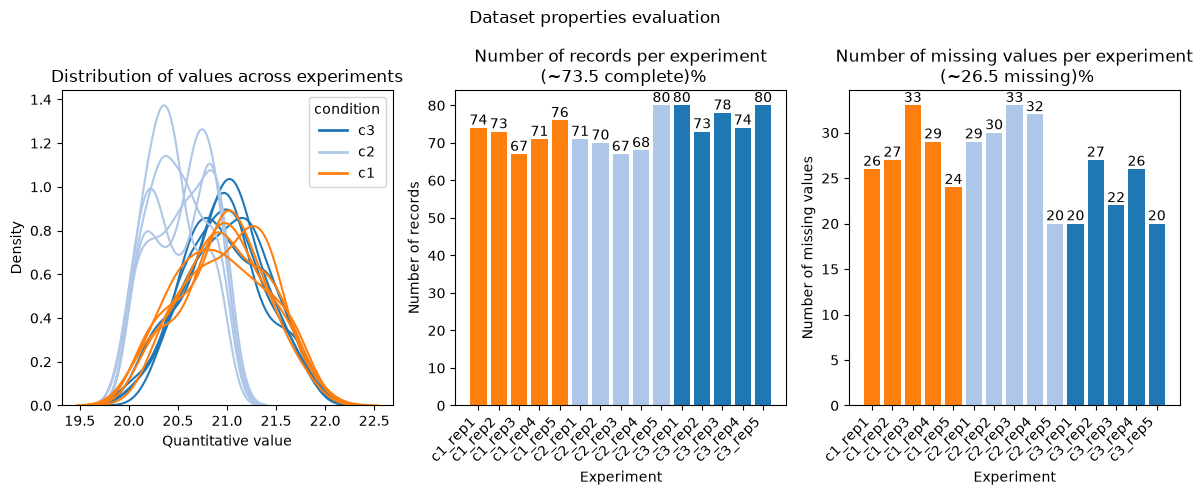

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
plot_density(dataset=dataset.log2_transform(), ax=ax[0])
plot_record_frequency(dataset=dataset, ax=ax[1], title="Number of records per experiment\n")
plot_missing_values(dataset=dataset, ax=ax[2], title="Number of missing values per experiment\n")
plt.suptitle('Dataset properties evaluation')
plt.tight_layout()
plt.show()

Optionally, you can impute the missing values. Each imputation/transformation step returns a new `ProteinsDataset` object that you can keep modifying.

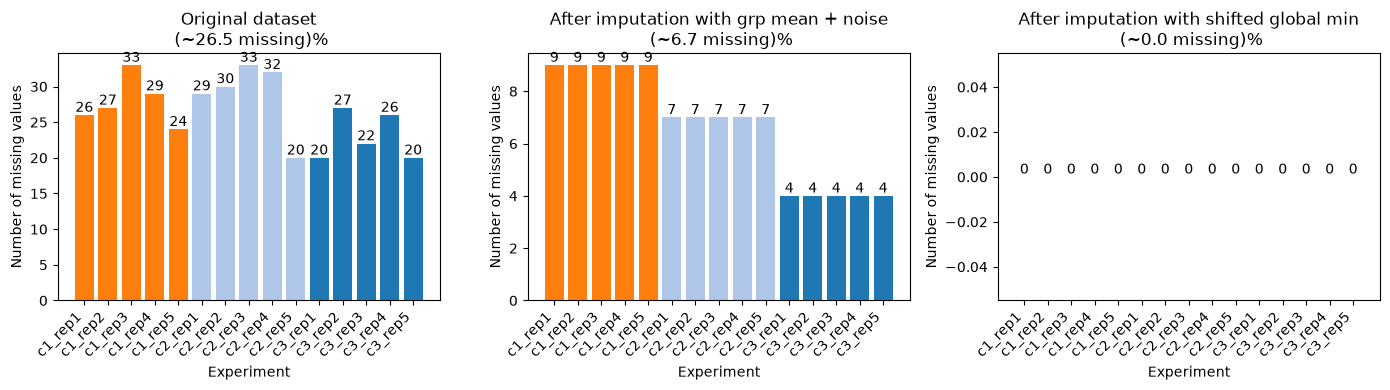

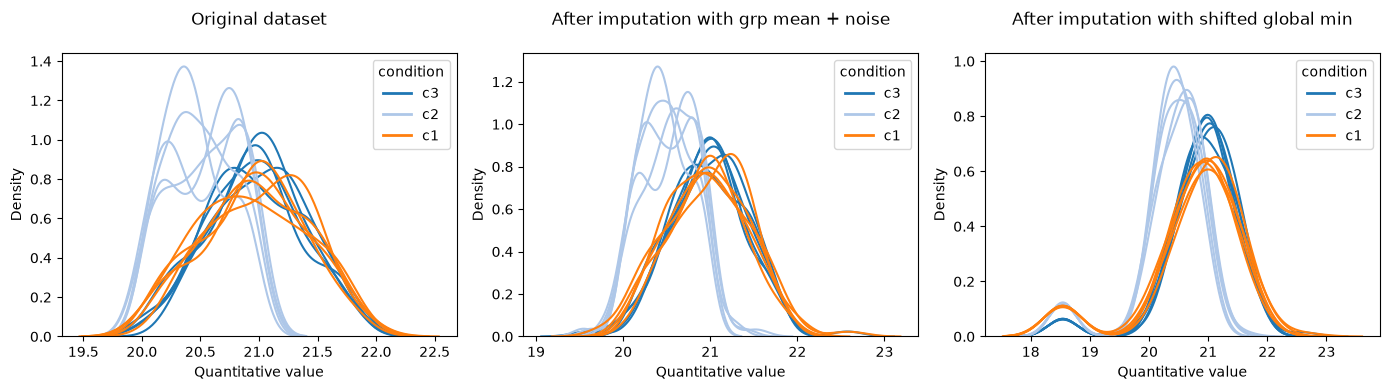

In [49]:
# perform missing value imputation on log2 transformed data
l2_dset = dataset.log2_transform()

# for each group impute each protein with the with-in group mean value + some random noise
grp_mean_l2_imputed_dset = l2_dset.impute(method='group row mean', random_noise=True)

# impute the rest missing values by the global min of the dataset shifted by a fixed number
l2_imputed_dset = grp_mean_l2_imputed_dset.impute(method='global min', shift=1.0)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plot_missing_values(dataset=l2_dset, ax=ax[0], title='Original dataset\n')
plot_missing_values(dataset=grp_mean_l2_imputed_dset, ax=ax[1], title='After imputation with grp mean + noise\n')
plot_missing_values(dataset=l2_imputed_dset, ax=ax[2], title='After imputation with shifted global min\n')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plot_density(dataset=l2_dset, ax=ax[0], title='Original dataset\n')
plot_density(dataset=grp_mean_l2_imputed_dset, ax=ax[1], title='After imputation with grp mean + noise\n')
plot_density(dataset=l2_imputed_dset, ax=ax[2], title='After imputation with shifted global min\n')
plt.tight_layout()
plt.show()


The ``PairwiseComparisonTTestFC`` class, will perform a t-test and apply a fold change rule, to identify differentially abundant records. By default, t-test uses log2 transformed values, whereas fold change calculation, uses raw values. The ``compare`` comparison results is a Pandas data frame, with the protein id, in this example, stored in the row index. You can use the index to merge the comparison results back to the table with the input values.

In [50]:
# back transform imputed dataset to the original scale, before starting the pairwise comparison
imputed_dataset = grp_mean_l2_imputed_dset.log2_backtransform()

comparison = PairwiseComparisonTTestFC(imputed_dataset, condition_a='c1', condition_b='c2', )
ttest_results = comparison.eval(pval_adj_method='fdr_bh')
ttest_results.head(3)

,p-value,t-statistic,adj-p-value,fold change,log2 fold change
protein_id,,,,,
p0,0.040585,2.439669,0.069807,1.458720,0.544703
p1,0.016610,3.017999,0.035711,1.485345,0.570798
p10,0.580283,0.576264,0.688876,1.062992,0.088130


The result of ``PairwiseComparisonTTestFC`` comparison can be passed directly to ``plot_volcano`` function, to create a volcano plot. Use standard ``matplotlib`` syntax to stylize the plot.

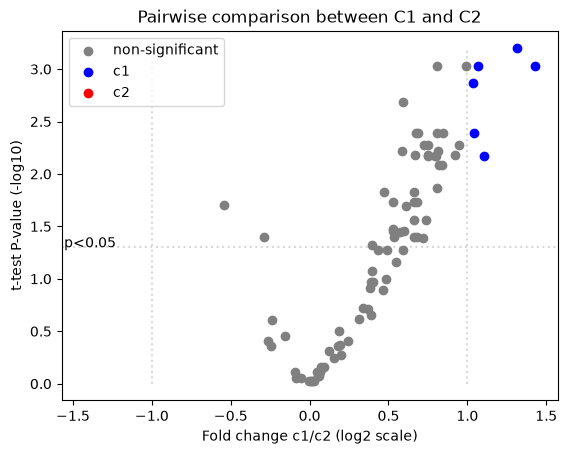

In [51]:
ax = plot_volcano(ttest_results, pval_col='adj-p-value', fc_col='fold change', condition_a='c1', condition_b='c2')
ax.set_title('Pairwise comparison between C1 and C2')
plt.show()

Convert a dataset to a Pandas data frame, using the ``to_table`` method. The record id is stored as row index, and you can merge comparison results to that table via this relationship.

You can also plot the values of an individual record across experiments. Use standard ``matplotlib`` syntax to stylize the plot.

In [1]:
fix, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_record_across_experiments(
    dataset=imputed_dataset,
    plot_type="jitter",
    record_id="p0",
    log_transform=True,
    ax=ax[0],
    show_experiment_names=True,
    text_annotation_size=8
)
plot_record_across_experiments(
    dataset=imputed_dataset,
    plot_type="bar",
    record_id="p0",
    log_transform=True, 
    ax=ax[1],
    text_rotation=45,
    text_round_digits=2
)

ax[1].set_ylim(0, 25)

for i in [0, 1]:
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.show()

NameError: name 'plt' is not defined

In [53]:
output_df = imputed_dataset.to_table()
output_df = output_df.merge(ttest_results, left_index=True, right_index=True, how='outer')
output_df.head(4)

# output_df.to_csv('dest_dir/pairwise_comparison.csv', sep='\t', index=True)   # standard pandas flow

,c1_rep1,c1_rep2,c1_rep3,c1_rep4,c1_rep5,c2_rep1,c2_rep2,c2_rep3,c2_rep4,c2_rep5,c3_rep1,c3_rep2,c3_rep3,c3_rep4,c3_rep5,p-value,t-statistic,adj-p-value,fold change,log2 fold change
protein_id,,,,,,,,,,,,,,,,,,,,
p0,1748947.964,2.655666e+06,1812807.047,3.179831e+06,3.002007e+06,1.860373e+06,1.357721e+06,1.668177e+06,2.087117e+06,1.526709e+06,2.558776e+06,2.655657e+06,2115434.782,2.889376e+06,2.654131e+06,0.040585,2.439669,0.069807,1.458720,0.544703
p1,1689613.957,1.726866e+06,1953790.640,2.447525e+06,2.877006e+06,1.438315e+06,1.198348e+06,1.864607e+06,1.284801e+06,1.414141e+06,2.285008e+06,3.070692e+06,3149289.453,2.830360e+06,2.264705e+06,0.016610,3.017999,0.035711,1.485345,0.570798
p10,1757091.693,1.536626e+06,1149483.961,1.600724e+06,1.675482e+06,2.052588e+06,1.135116e+06,1.374370e+06,1.297363e+06,1.402528e+06,2.571566e+06,3.535483e+06,3648111.452,2.664608e+06,3.233381e+06,0.580283,0.576264,0.688876,1.062992,0.088130
p11,2596847.916,2.592526e+06,2686205.008,2.386290e+06,2.684965e+06,1.461644e+06,1.528603e+06,1.837380e+06,1.226513e+06,1.329203e+06,1.624380e+06,1.998983e+06,1660887.127,1.920664e+06,1.852346e+06,0.000047,7.928952,0.000939,1.753519,0.810253
